## Module 4: Cancer

## Team Members:
Roy Chen

Theresa Breckley

### Apoptosis-Related Gene Expression Patterns in Breast Cancer and Their Relationship to Tumor Stage




## Project Goal:
The goal of this project is to investigate whether apoptosis-related gene expression patterns can distinguish subgroups of breast cancer tumors and determine whether these patterns are predictive of tumor stage



## Disease Background:

Breast cancer is one of the most commonly diagnosed cancers worldwide and the most frequently diagnosed cancer among women. It arises from abnormal cell growth in breast tissue, most commonly in the epithelial cells lining the milk ducts or lobules.
Breast cancer is a heterogeneous disease, meaning it consists of multiple subtypes with distinct molecular and clinical characteristics. These subtypes are often classified based on receptor expression:
* Hormone receptor–positive (HR+): expresses estrogen (ER) and/or progesterone (PR) receptors
* HER2-positive: overexpression of the HER2 protein promotes aggressive growth
* Triple-negative breast cancer (TNBC): lacks ER, PR, and HER2 expression and is often more aggressive with fewer targeted treatment options



Apoptosis is a programmed cell death process that removes damaged, or unnecessary cells to maintain healthy tissue function. In normal cells, apoptosis is tightly regulated through cell cycle checkpoints, particularly at the G1, G2, and G0 phases, which act as check points to detect any abnormalities in cell reproduction.

At the G1 checkpoint, cells assess DNA integrity before replication. If any damage is detected, the tumor suppressor protein p53 can pause the cell cycle to allow repair or trigger apoptosis. The G2 checkpoint serves as a second control point after DNA replication, ensuring that genetic material has been accurately copied; cells with unrepaired damage are triggered to undergo apoptosis. In contrast, the G0 phase represents a resting state where cells exit the cycle to prevent unnecessary division, helping maintain tissue stability.

Cancer cells acquire the ability to resist apoptosis by disrupting these checkpoints. Mutations in key regulatory genes, such as TP53, allow cells with damaged DNA to bypass G1 and G2 control mechanisms and continue dividing uncontrollably.

Mutations in TP53 are common in aggressive forms of breast cancer, particularly triple-negative breast cancer. Loss of p53 function prevents damaged cells from undergoing apoptosis, allowing them to survive and accumulate additional mutations.
Additionally, many breast cancers exhibit overexpression of BCL-2, which inhibits apoptosis by blocking mitochondrial pathways of cell death. This imbalance between pro-apoptotic and anti-apoptotic signaling allows cancer cells to evade normal death mechanisms.
Disruption of apoptosis also contributes to treatment resistance, as therapies like chemotherapy and radiation rely on activating apoptotic pathways to kill cancer cells





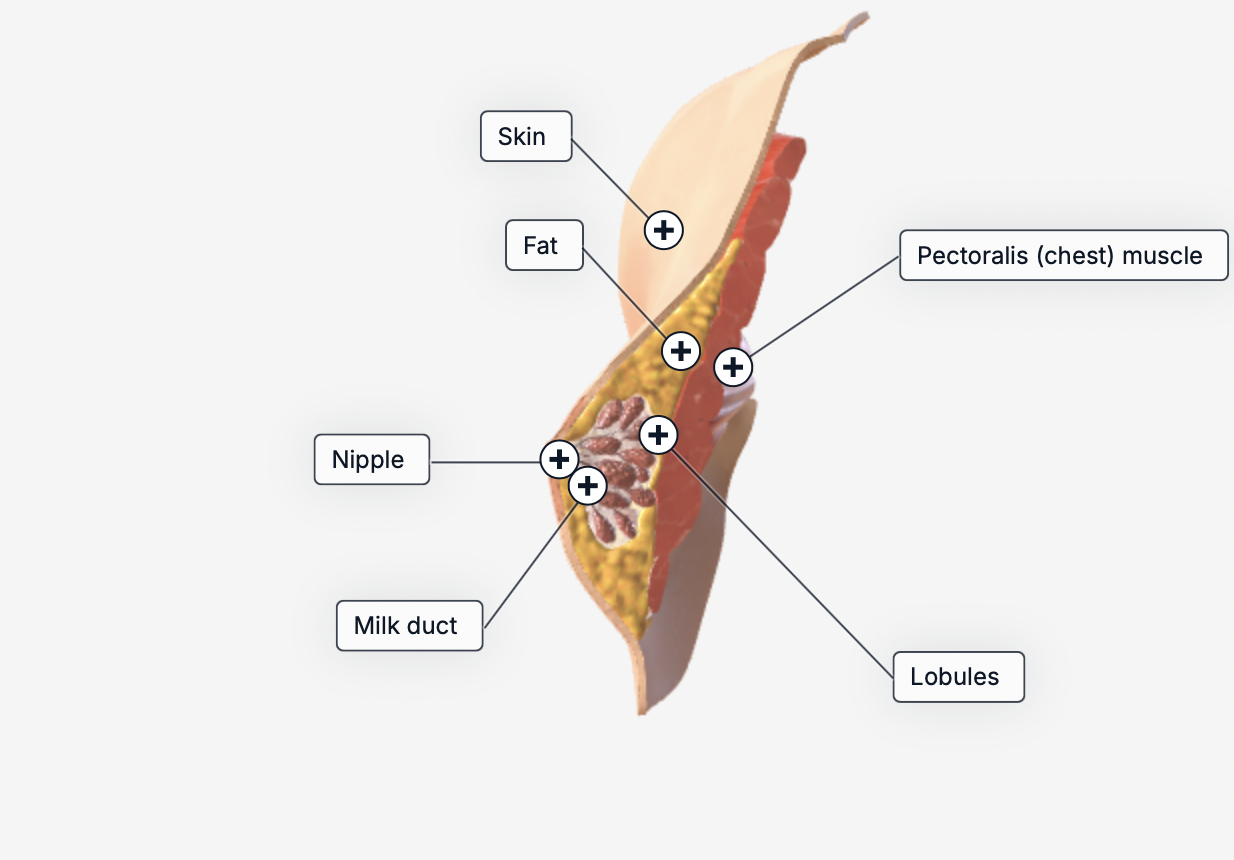

Anatomy of the breast showing ducts and lobules, where most breast cancers originate 
(Image provided by Susan G Komen)

## Prevalence, Risk Factors, and Treatment

Cancer is one of the leading causes of death worldwide and a major public health concern. In the United States, the most commonly diagnosed cancers include breast, prostate, lung, and colorectal cancer with lung cancer in the highest mortality rate due to its aggressive progression and late-stage detection.


Breast cancer is one of the most commonly diagnosed cancers worldwide and the most frequently diagnosed cancer among women. In the United States, it is also a leading cause of cancer-related death, although survival rates have improved significantly due to early detection and advances in treatment. 

Cancer incidence increases significantly with age, as mutations accumulate over time. Globally, cancer rates are rising due to population aging, environmental exposures, and lifestyle factors.


## Risk Factors:
Cancer risk can a rise from a combination factors such as genetic, environmental, and lifestyle factors. mutations in tumor suppressor genes like P53 and oncogenes, which increase susceptibility to cancer by disrupting normal cell cycle regulation and apoptosis can increase the chance of recieving cancer.

 While lifestyle factors like smoking, poor diet, physical inactivity, alcohol consumption, and exposure to UV radiation and air pollution are major contributors to cancer development.

People in more underdeveloped regions often have a higher cancer rate compare to more developed regions do due lack of access to health care, early screening and limited access to preventive care and treatment often experience higher mortality rates.

## Standard of Care Treatments
Current standard cancer treatments includes: 

* Surgery removes localized tumors
* Chemotherapy targets rapidly dividing cellss by inducing damage to the DNA
* Radiation therapy damages DNA in cancer cells to trigger apotosis
* Targeted therapy focuses on target certain cell
* Immunotherapy enhances the immune system’s ability to recognize and target cancer cells
* Apoptosis is controlled by a balance between pro apoptotic and anti apoptotic signals, Pro apoptotic (e.g., BAX, BAK) promote cell death while Anti apoptotic (BCL-2) prevent apoptosis.

In cancer, these pathways are often disrupted for example the loss of TP53 function prevents apoptosis while an overexpression of BCL-2 blocks cell death, allowing abnormal cells to survive. These changes enable cancer cells to evade death signals, continue proliferating, and resist therapies that rely on apoptosis.


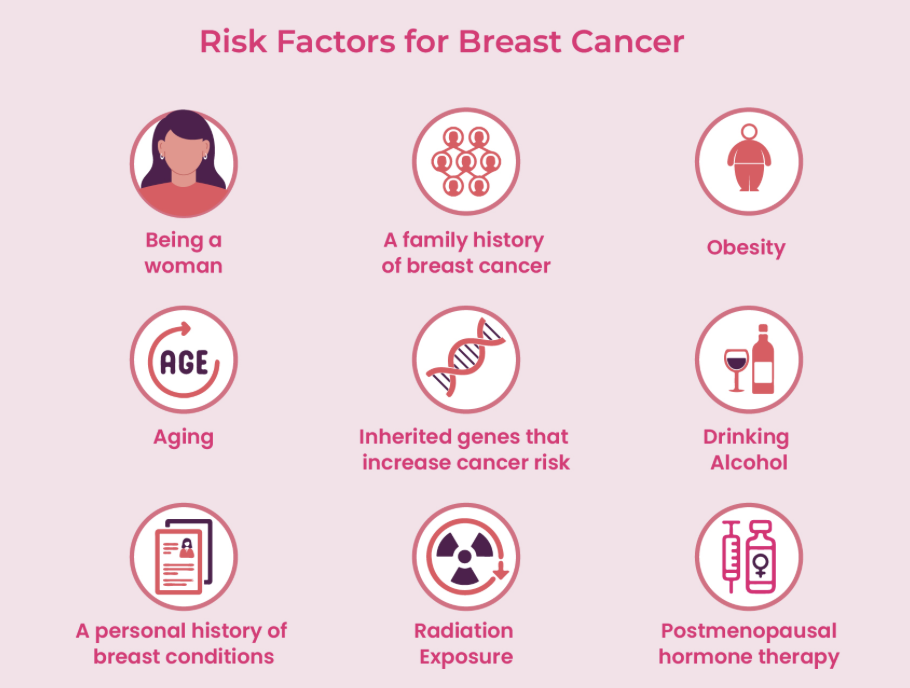

risk factors contributing to cancer development
(Image by drsanjaysharmacancer.com)

## Data-Set: 

**Dataset Description**

The dataset used in this project is derived from The Cancer Genome Atlas, or TCGA, and includes RNA sequencing data paired with clinical metadata.

The gene expression file is organized as genes by samples. Each value represents the expression level of a gene in a tumor sample using log₂(TPM + 1), where TPM stands for Transcripts Per Million. This normalization helps make expression values more comparable across genes and samples.

The metadata file contains clinical information for each sample, including cancer type, tumor stage, and patient characteristics. For this project, we focus only on breast cancer samples, labeled as BRCA in the metadata.

Because our biological focus is the cancer hallmark of resisting cell death, we selected apoptosis-related genes, including pro-apoptotic genes, anti-apoptotic genes, caspases, and key pathway regulators. By combining these gene expression values with tumor stage information, we can test whether apoptosis-related expression patterns are associated with breast cancer progression.

The genes selected for this analysis are associated with apoptosis pathways. These include:

TP53 (tumor suppressor gene involved in DNA damage response)
BAX (pro-apoptotic regulator that promotes cell death)
BCL2 (anti-apoptotic protein that inhibits cell death)
CASP3 (caspase involved in execution of apoptosis)
These genes were chosen because they play key roles in regulating programmed cell death and are commonly dysregulated in breast cancer.


In [27]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)

sns.set_theme(style="whitegrid")

# -----------------------------
# File paths
# -----------------------------
# All project data files are stored in the data folder for this repository.
# This absolute path matches Theresa's local computer.
# If this notebook is run from inside the GitHub repository on another computer,
# the fallback below will use the local "data" folder instead.

base_path = Path(r"C:\Users\15712\OneDrive - University of Virginia\School\OneDrive - University of Virginia\Comp Mod 4\Module-4-Cancer_breckley_chen\data")

# Fallback for GitHub/class submission if the notebook is opened from the repo folder.
if not base_path.exists():
    base_path = Path("data")

print("Using data folder:", base_path)

# Metadata completeness file, if needed for data background/exploration
metadata_percent_nonNA_path = base_path / "GSE62944_metadata_percent_nonNA_by_cancer_type.csv"

# Training files
training_metadata_path = base_path / "TRAINING_SET_GSE62944_metadata.csv"
training_expression_path = base_path / "TRAINING_SET_GSE62944_subsample_log2TPM.csv"

# Validation files
validation_metadata_path = base_path / "VALIDATION_SET_GSE62944_metadata.csv"
validation_expression_path = base_path / "VALIDATION_SET_GSE62944_subsample_log2TPM.csv"

# Test files
test_metadata_path = base_path / "TEST_SET_GSE62944_metadata.csv"
test_expression_path = base_path / "TEST_SET_GSE62944_subsample_log2TPM.csv"

# Quick path check so errors are easier to understand.
required_paths = [
    training_metadata_path,
    training_expression_path,
    validation_metadata_path,
    validation_expression_path,
    test_metadata_path,
    test_expression_path,
]

missing_paths = [p for p in required_paths if not p.exists()]
if missing_paths:
    print("The following files were not found:")
    for p in missing_paths:
        print(" -", p)
    raise FileNotFoundError("One or more required data files could not be found. Check base_path above.")
else:
    print("All required training, validation, and test files were found.")


Using data folder: C:\Users\15712\OneDrive - University of Virginia\School\OneDrive - University of Virginia\Comp Mod 4\Module-4-Cancer_breckley_chen\data
All required training, validation, and test files were found.


**Load Training Data**

The first step is to load the training expression matrix and the matching clinical metadata. The expression matrix is organized as genes by samples, while the metadata is organized as samples by clinical features.

Loading both files allows us to connect each tumor sample’s gene expression profile with its cancer type and tumor stage.

The expression matrix is organized as genes × samples, while the metadata is organized as samples × clinical features.

In [28]:
# Load training metadata and expression data
metadata_df = pd.read_csv(training_metadata_path, index_col=0)
data = pd.read_csv(training_expression_path, index_col=0)

print("Training expression data shape (genes x samples):", data.shape)
print("Training metadata shape (samples x features):", metadata_df.shape)
print("\nMetadata columns:")
print(metadata_df.columns.tolist())

Training expression data shape (genes x samples): (15716, 1802)
Training metadata shape (samples x features): (1802, 29)

Metadata columns:
['cancer_type', 'bcr_patient_barcode', 'gender', 'race', 'ethnicity', 'age_at_diagnosis', 'ajcc_pathologic_tumor_stage', 'ajcc_nodes_pathologic_pn', 'ajcc_metastasis_pathologic_pm', 'ajcc_tumor_pathologic_pt', 'tumor_status', 'histologic_diagnosis', 'history_other_malignancy', 'history_thyroid_disease', 'history_thyroid_disease_other', 'history_reflux_disease_indicator', 'history_hormonal_contraceptives_use', 'pregnancies_count_miscarriage', 'jewish_religion_heritage_indicator', 'tobacco_smoking_age_started', 'family_history_cancer_type', 'OS', 'OS.time', 'DSS', 'DSS.time', 'DFI', 'DFI.time', 'PFI', 'PFI.time']


**Subset to Breast Cancer (BRCA) and Apoptosis Genes**

To keep the analysis focused, we first subset the dataset to breast cancer samples only. In the metadata, breast cancer samples are labeled as BRCA.

Next, we subset the expression matrix to a selected group of apoptosis-related genes. These genes represent both sides of apoptosis regulation: genes that promote cell death and genes that help cells avoid death. This is important because one hallmark of cancer is the ability of abnormal cells to resist apoptosis and survive when they would normally be removed.

This step creates the main expression matrix used throughout the rest of the analysis.

In [29]:
# Subset metadata to breast cancer
brca_metadata = metadata_df[metadata_df["cancer_type"] == "BRCA"].copy()
print("BRCA metadata shape:", brca_metadata.shape)

# Apoptosis / resisting apoptosis gene set
desired_gene_list = [
    "BCL2", "BCL2L1", "MCL1", "BAX", "BAK1",
    "TP53", "CASP3", "CASP8", "CASP9",
    "FAS", "FADD", "XIAP", "BIRC5",
    "BAD", "BID", "BBC3", "PMAIP1"
]

available_genes = [gene for gene in desired_gene_list if gene in data.index]
missing_genes = [gene for gene in desired_gene_list if gene not in data.index]

print("Number of requested genes:", len(desired_gene_list))
print("Number of genes found in dataset:", len(available_genes))
print("Genes found:", available_genes)
print("Missing genes:", missing_genes)

# Subset expression data to BRCA samples and apoptosis genes
brca_sample_ids = brca_metadata.index.intersection(data.columns)
brca_data = data.loc[available_genes, brca_sample_ids]

print("\nBRCA expression subset shape (genes x BRCA samples):", brca_data.shape)
brca_data.head()

BRCA metadata shape: (80, 29)
Number of requested genes: 17
Number of genes found in dataset: 17
Genes found: ['BCL2', 'BCL2L1', 'MCL1', 'BAX', 'BAK1', 'TP53', 'CASP3', 'CASP8', 'CASP9', 'FAS', 'FADD', 'XIAP', 'BIRC5', 'BAD', 'BID', 'BBC3', 'PMAIP1']
Missing genes: []

BRCA expression subset shape (genes x BRCA samples): (17, 80)


,TCGA-E9-A1NI-01A-11R-A14D-07,TCGA-E2-A1LK-01A-21R-A14D-07,TCGA-BH-A0B2-01A-11R-A10J-07,TCGA-E2-A107-01A-11R-A10J-07,TCGA-LL-A5YN-01A-11R-A28M-07,TCGA-BH-A0DQ-01A-11R-A084-07,TCGA-D8-A73X-01A-11R-A32P-07,TCGA-AR-A0TP-01A-11R-A084-07,TCGA-E2-A1IF-01A-11R-A144-07,TCGA-EW-A6SD-01A-12R-A33J-07,...,TCGA-D8-A1JA-01A-11R-A13Q-07,TCGA-A2-A0D0-01A-11R-A00Z-07,TCGA-A8-A07B-01A-11R-A00Z-07,TCGA-C8-A275-01A-21R-A16F-07,TCGA-AO-A1KQ-01A-11R-A13Q-07,TCGA-E9-A5UP-01A-11R-A28M-07,TCGA-AR-A24T-01A-11R-A169-07,TCGA-D8-A1XB-01A-11R-A14D-07,TCGA-E9-A245-01A-22R-A16F-07,TCGA-WT-AB44-01A-11R-A41B-07
BCL2,5.248282,0.985832,5.784362,4.152444,3.692885,4.763121,5.221591,5.376440,4.050835,1.936183,...,1.693603,1.996426,5.779014,2.672941,5.405569,5.532695,5.958578,6.085538,6.243730,1.873949
BCL2L1,7.818040,6.874837,7.115444,7.566785,6.954511,7.408560,7.460900,6.024670,6.833883,7.256705,...,7.514368,6.689359,6.784440,7.055031,7.299693,8.759745,7.486974,7.529951,6.777458,6.381661
MCL1,7.816182,8.140580,8.165650,8.071209,7.278051,8.035222,8.193623,7.856121,8.412290,8.395989,...,9.078687,8.175704,8.279657,8.363384,7.513230,8.424985,8.756147,8.547165,7.503071,8.404597
BAX,6.720700,7.189939,6.504814,7.466535,7.662465,6.634294,6.585344,5.994697,7.414525,6.308539,...,5.301869,6.917972,6.257364,6.167569,7.180470,7.320232,5.802379,6.468790,5.992391,6.350984
BAK1,4.584133,5.334564,4.855286,4.845804,5.442022,5.610309,4.346540,4.705020,4.831672,4.301206,...,4.254277,5.583720,4.708609,5.048889,4.169633,4.340381,4.749268,4.740960,3.371286,3.386362


## Data Analysis: 

**Methods**

This project uses both unsupervised and supervised machine learning.

First, we use **principal component analysis**, or PCA, to reduce the apoptosis gene expression data into two main components. PCA helps us visualize whether breast cancer samples show patterns or separation based on apoptosis-related gene expression.

Next, we use **K-means clustering** as an unsupervised learning method. K-means groups samples based only on similarity in gene expression, without using the tumor stage labels. This allows us to test whether BRCA tumors naturally form expression-based subgroups.

Finally, we use **logistic regression** as a supervised learning method. Unlike PCA and K-means, logistic regression uses known tumor stage labels during training. The model attempts to predict whether each tumor is Early stage or Late stage based on apoptosis-related gene expression.

The main performance metric used for supervised learning is **balanced accuracy**. Balanced accuracy is useful because it gives equal weight to both classes, which is important if the number of Early and Late stage tumors is not perfectly balanced.

### ***Unsupervised Learning Model***
The unsupervised portion of this project asks whether breast cancer samples show natural structure based on apoptosis-related gene expression alone. Importantly, these methods do not use the tumor stage labels to form groups. Instead, they allow us to explore whether expression patterns appear before applying a supervised prediction model.

**Clean Tumor Stage Labels**

The supervised learning target for this project is tumor stage. The metadata column used for this is `ajcc_pathologic_tumor_stage`.

The original tumor stage labels contain several specific categories, such as Stage I, Stage II, Stage III, and Stage IV. To make the classification problem simpler and more appropriate for a first-pass model, we convert these labels into two broader groups:

- **Early stage:** Stage I or Stage II
- **Late stage:** Stage III or Stage IV

This simplified grouping allows the model to focus on whether apoptosis-related gene expression differs between earlier and more advanced breast cancer tumors.


In [30]:
# Keep only metadata rows that match the expression matrix
brca_metadata = brca_metadata.loc[brca_sample_ids].copy()

# Make age numeric for cleaner summaries
brca_metadata["age_at_diagnosis"] = pd.to_numeric(
    brca_metadata["age_at_diagnosis"], errors="coerce"
)

# Inspect tumor stage values
print(brca_metadata["ajcc_pathologic_tumor_stage"].value_counts(dropna=False))

def simplify_stage(stage_value):
    """
    Convert AJCC pathologic tumor stage into a binary classification target.

    Early = Stage I or Stage II
    Late = Stage III or Stage IV

    Important: we check Stage IV and Stage III before Stage I so that
    labels like 'Stage III' are not accidentally counted as Stage I.
    """
    if pd.isna(stage_value):
        return np.nan

    stage_str = str(stage_value).upper().strip()

    if "STAGE IV" in stage_str or stage_str.startswith("IV"):
        return "Late"
    elif "STAGE III" in stage_str or stage_str.startswith("III"):
        return "Late"
    elif "STAGE II" in stage_str or stage_str.startswith("II"):
        return "Early"
    elif "STAGE I" in stage_str or stage_str.startswith("I"):
        return "Early"
    else:
        return np.nan

brca_metadata["stage_group"] = brca_metadata["ajcc_pathologic_tumor_stage"].apply(simplify_stage)

print("\nStage group counts:")
print(brca_metadata["stage_group"].value_counts(dropna=False))

print("\nAge summary:")
print(brca_metadata["age_at_diagnosis"].describe())


ajcc_pathologic_tumor_stage
Stage IIA          23
Stage IIB          14
Stage IIIA         11
Stage I             7
Stage IA            7
Stage IIIC          5
NaN                 4
Stage IV            4
Stage IIIB          3
Stage IB            1
[Not Available]     1
Name: count, dtype: int64

Stage group counts:
stage_group
Early    52
Late     23
NaN       5
Name: count, dtype: int64

Age summary:
count    76.000000
mean     59.078947
std      12.609798
min      36.000000
25%      48.750000
50%      58.500000
75%      69.250000
max      84.000000
Name: age_at_diagnosis, dtype: float64


**Tumor Stage Cleaning Interpretation**

After filtering to BRCA samples and removing samples without usable stage labels, the dataset contains tumors grouped into Early and Late stage categories. This cleaned stage variable is used as the target for supervised learning later in the notebook.

This step is important because machine learning models require consistent labels. The original AJCC stage labels are more detailed, but the Early versus Late grouping creates a clearer binary classification task for this project.

**PCA Preparation**

Before running PCA, the expression matrix must be transposed so that rows represent tumor samples and columns represent genes. This format is required by scikit-learn.

The gene expression values are also standardized before PCA. Standardization gives each gene a mean of 0 and a standard deviation of 1. This is important because PCA is sensitive to scale, and genes with larger expression ranges could otherwise dominate the analysis.



In [31]:
# Transpose so rows = samples and columns = genes
X = brca_data.T

# Standardize the expression values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"], index=X.index)
pca_df = pca_df.join(brca_metadata)

# Add one key gene for coloring
if "BCL2" in X.columns:
    pca_df["BCL2_expression"] = X["BCL2"]

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)
pca_df.head()

Explained variance ratio:
[0.1987766  0.15712808]


,PC1,PC2,cancer_type,bcr_patient_barcode,gender,race,ethnicity,age_at_diagnosis,ajcc_pathologic_tumor_stage,ajcc_nodes_pathologic_pn,...,OS,OS.time,DSS,DSS.time,DFI,DFI.time,PFI,PFI.time,stage_group,BCL2_expression
TCGA-E9-A1NI-01A-11R-A14D-07,-0.246504,0.978967,BRCA,TCGA-E9-A1NI,FEMALE,WHITE,NOT HISPANIC OR LATINO,51.0,Stage IIA,N0,...,0.0,300.0,0.0,300.0,0.0,300.0,0.0,300.0,Early,5.248282
TCGA-E2-A1LK-01A-21R-A14D-07,-5.239930,-1.590538,BRCA,TCGA-E2-A1LK,FEMALE,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,84.0,Stage IIIC,N3a,...,1.0,266.0,1.0,266.0,1.0,155.0,1.0,155.0,Late,0.985832
TCGA-BH-A0B2-01A-11R-A10J-07,0.263982,-0.156312,BRCA,TCGA-BH-A0B2,FEMALE,WHITE,NOT HISPANIC OR LATINO,43.0,Stage I,N0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Early,5.784362
TCGA-E2-A107-01A-11R-A10J-07,-1.693936,1.653981,BRCA,TCGA-E2-A107,FEMALE,WHITE,NOT HISPANIC OR LATINO,54.0,Stage IIIA,N2a,...,0.0,1047.0,0.0,1047.0,0.0,1047.0,0.0,1047.0,Late,4.152444
TCGA-LL-A5YN-01A-11R-A28M-07,-3.004212,1.201851,BRCA,TCGA-LL-A5YN,FEMALE,BLACK OR AFRICAN AMERICAN,NOT HISPANIC OR LATINO,46.0,Stage IIA,N0 (i-),...,0.0,447.0,0.0,447.0,0.0,447.0,0.0,447.0,Early,3.692885


## PCA Visualization

The first PCA plot is colored by tumor stage group to examine whether Early and Late stage tumors separate based on apoptosis-related gene expression.

The second PCA plot is colored by BCL2 expression. BCL2 is an anti-apoptotic gene, meaning it can help cells avoid programmed cell death. Because resisting apoptosis is a key cancer hallmark, BCL2 is biologically relevant to this project.

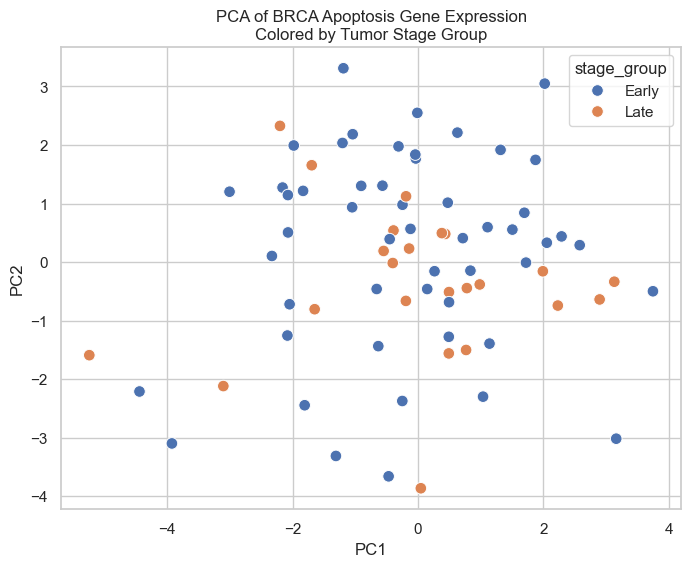

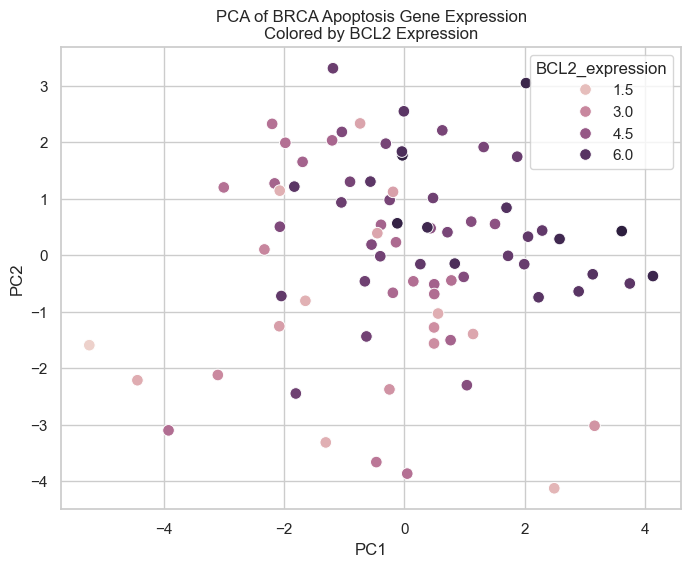

In [32]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="stage_group",
    s=70
)
plt.title("PCA of BRCA Apoptosis Gene Expression\nColored by Tumor Stage Group")
plt.show()

if "BCL2_expression" in pca_df.columns:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=pca_df,
        x="PC1",
        y="PC2",
        hue="BCL2_expression",
        s=70
    )
    plt.title("PCA of BRCA Apoptosis Gene Expression\nColored by BCL2 Expression")
    plt.show()


**PCA Interpretation:**

The PCA plots provide a visual summary of variation in apoptosis-related gene expression across BRCA tumor samples.

If Early and Late stage tumors form clearly separated groups, that would suggest apoptosis-related gene expression is strongly associated with tumor stage. If the groups overlap, that suggests apoptosis-related genes alone may not fully explain tumor stage differences.

In this project, the PCA visualization should be interpreted cautiously. PCA is useful for seeing broad patterns, but it does not prove that apoptosis genes can accurately predict tumor stage. Instead, it helps us decide whether there is enough visible structure to justify moving forward with supervised learning.

**K-means Clustering**

K-means clustering is used as a second unsupervised learning method. Unlike logistic regression, K-means does not use tumor stage labels. Instead, it groups samples based on similarity in apoptosis-related gene expression.

In this analysis, K-means is used to test whether BRCA tumors naturally form expression-based subgroups. If the clusters also correspond to tumor stage, that could suggest that apoptosis-related expression patterns are connected to breast cancer progression.

c:\Users\15712\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


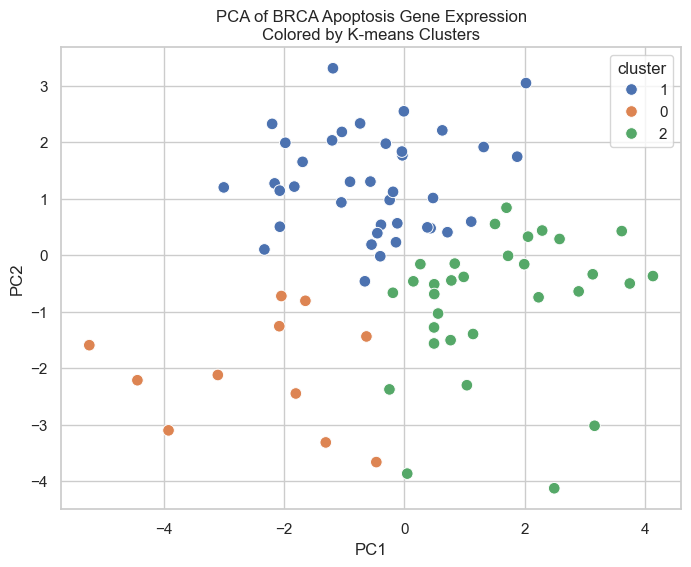

Cluster counts:
cluster
1    38
2    31
0    11
Name: count, dtype: int64


In [33]:
# K-means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

pca_df["cluster"] = clusters.astype(str)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="cluster",
    s=70
)
plt.title("PCA of BRCA Apoptosis Gene Expression\nColored by K-means Clusters")
plt.show()

print("Cluster counts:")
print(pca_df["cluster"].value_counts())

**Clustering Interpretation**

The K-means clustering plot shows whether breast cancer tumors group into distinct apoptosis-expression patterns.

If the clusters are clearly separated on the PCA plot, this suggests that the selected apoptosis genes capture meaningful differences among BRCA tumors. However, if the clusters overlap or do not match tumor stage groups, then the clusters may reflect other biological differences that are not directly related to Early versus Late tumor stage.

This is important because unsupervised learning can reveal structure in the data, but it does not automatically explain what that structure means. The clusters should therefore be interpreted as exploratory evidence rather than a final conclusion.

### ***Supervised Learning Model***

The supervised learning portion of this project tests whether apoptosis-related gene expression can predict tumor stage group.

For this analysis, we use logistic regression to classify each BRCA tumor as either Early stage or Late stage. Logistic regression is a good first model because it is simple, interpretable, and appropriate for binary classification.

**Train Baseline Logistic Regression Model**

Before training the model, we remove samples that do not have a usable stage group. The feature matrix, `X_train`, contains apoptosis-related gene expression values, and the target variable, `y_train`, contains the Early or Late stage label.

The expression values are standardized before modeling so that all genes are placed on the same scale. The logistic regression model is then trained on the training data and evaluated first on that same training data to establish a baseline.

In [34]:
# -----------------------------
# Prepare training data for supervised learning
# -----------------------------

# Keep only samples with a usable stage group
train_valid_samples = brca_metadata.dropna(subset=["stage_group"]).index

# X_train: samples x apoptosis genes
X_train = brca_data.T.loc[train_valid_samples].copy()

# y_train: early vs late tumor stage group
y_train = brca_metadata.loc[train_valid_samples, "stage_group"].copy()

print("Training feature matrix shape:", X_train.shape)
print("Training target shape:", y_train.shape)
print("\nTraining class balance:")
print(y_train.value_counts())

# Scale the gene expression features using only the training data
ml_scaler = StandardScaler()
X_train_scaled = ml_scaler.fit_transform(X_train)

# Fit logistic regression model
log_reg_model = LogisticRegression(max_iter=1000, random_state=42)
log_reg_model.fit(X_train_scaled, y_train)

# Predict on the same training data to estimate in-sample performance
y_train_pred = log_reg_model.predict(X_train_scaled)
y_train_scores = log_reg_model.predict_proba(X_train_scaled)[:, list(log_reg_model.classes_).index("Late")]

train_accuracy = accuracy_score(y_train, y_train_pred)
train_balanced_accuracy = balanced_accuracy_score(y_train, y_train_pred)

print("\nTraining accuracy:", train_accuracy)
print("Training balanced accuracy:", train_balanced_accuracy)

print("\nTraining classification report:")
print(classification_report(y_train, y_train_pred, zero_division=0))


Training feature matrix shape: (75, 17)
Training target shape: (75,)

Training class balance:
stage_group
Early    52
Late     23
Name: count, dtype: int64

Training accuracy: 0.7866666666666666
Training balanced accuracy: 0.7127926421404682

Training classification report:
              precision    recall  f1-score   support

       Early       0.81      0.90      0.85        52
        Late       0.71      0.52      0.60        23

    accuracy                           0.79        75
   macro avg       0.76      0.71      0.73        75
weighted avg       0.78      0.79      0.78        75



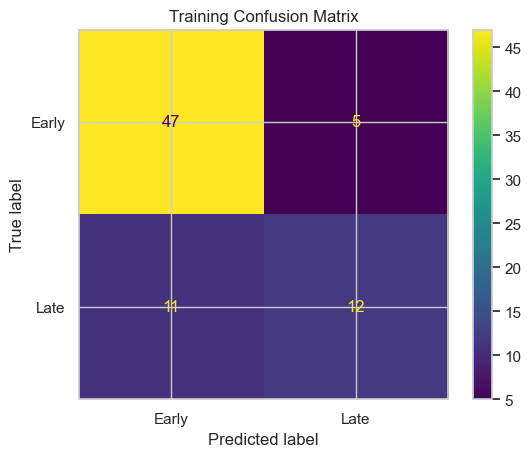

In [35]:
# Confusion matrix for training data
train_cm = confusion_matrix(y_train, y_train_pred, labels=log_reg_model.classes_)

train_disp = ConfusionMatrixDisplay(
    confusion_matrix=train_cm,
    display_labels=log_reg_model.classes_
)

train_disp.plot()
plt.title("Training Confusion Matrix")
plt.show()


**Validation Dataset Evaluation**

The validation dataset is used to evaluate how well the model performs on new samples that were not used during training.

This is an important step because a model can perform well on the data it was trained on but perform poorly on new data. By comparing training performance to validation performance, we can check whether the model is generalizing or overfitting.

The same BRCA filtering, apoptosis gene list, tumor stage cleaning, and scaling approach are applied to the validation data. However, the scaler and model are fit only on the training data, then applied to the validation data.

In [36]:
# -----------------------------
# Load validation data
# -----------------------------
# The validation dataset is used to evaluate and improve the model before
# touching the final test dataset.

validation_metadata_df = pd.read_csv(validation_metadata_path, index_col=0)
validation_data = pd.read_csv(validation_expression_path, index_col=0)

print("Validation expression data shape (genes x samples):", validation_data.shape)
print("Validation metadata shape (samples x features):", validation_metadata_df.shape)

# Subset validation data to BRCA samples
validation_brca_metadata = validation_metadata_df[validation_metadata_df["cancer_type"] == "BRCA"].copy()
validation_brca_sample_ids = validation_brca_metadata.index.intersection(validation_data.columns)

validation_brca_metadata = validation_brca_metadata.loc[validation_brca_sample_ids].copy()

# Apply the same stage cleaning function
validation_brca_metadata["stage_group"] = validation_brca_metadata["ajcc_pathologic_tumor_stage"].apply(simplify_stage)

print("\nValidation stage group counts:")
print(validation_brca_metadata["stage_group"].value_counts(dropna=False))

# Use the same genes that were available in the training data
validation_available_genes = [gene for gene in available_genes if gene in validation_data.index]
validation_missing_genes = [gene for gene in available_genes if gene not in validation_data.index]

print("\nValidation genes found:", validation_available_genes)
print("Validation genes missing:", validation_missing_genes)

if validation_missing_genes:
    raise ValueError("Some training genes are missing from validation data. Check gene names before continuing.")

validation_brca_data = validation_data.loc[available_genes, validation_brca_sample_ids]

# Keep only validation samples with usable stage group
validation_valid_samples = validation_brca_metadata.dropna(subset=["stage_group"]).index

X_validation = validation_brca_data.T.loc[validation_valid_samples].copy()
y_validation = validation_brca_metadata.loc[validation_valid_samples, "stage_group"].copy()

# Make sure validation columns are in the exact same order as training columns
X_validation = X_validation[X_train.columns]

print("\nValidation feature matrix shape:", X_validation.shape)
print("Validation target shape:", y_validation.shape)
print("\nValidation class balance:")
print(y_validation.value_counts())

# Transform validation data with the scaler fit on training data
X_validation_scaled = ml_scaler.transform(X_validation)

# Predict validation labels and scores
y_validation_pred = log_reg_model.predict(X_validation_scaled)
y_validation_scores = log_reg_model.predict_proba(X_validation_scaled)[:, list(log_reg_model.classes_).index("Late")]

validation_accuracy = accuracy_score(y_validation, y_validation_pred)
validation_balanced_accuracy = balanced_accuracy_score(y_validation, y_validation_pred)

print("\nValidation accuracy:", validation_accuracy)
print("Validation balanced accuracy:", validation_balanced_accuracy)

print("\nValidation classification report:")
print(classification_report(y_validation, y_validation_pred, zero_division=0))

Validation expression data shape (genes x samples): (15716, 1360)
Validation metadata shape (samples x features): (1360, 29)

Validation stage group counts:
stage_group
Early    56
Late     22
NaN       2
Name: count, dtype: int64

Validation genes found: ['BCL2', 'BCL2L1', 'MCL1', 'BAX', 'BAK1', 'TP53', 'CASP3', 'CASP8', 'CASP9', 'FAS', 'FADD', 'XIAP', 'BIRC5', 'BAD', 'BID', 'BBC3', 'PMAIP1']
Validation genes missing: []

Validation feature matrix shape: (78, 17)
Validation target shape: (78,)

Validation class balance:
stage_group
Early    56
Late     22
Name: count, dtype: int64

Validation accuracy: 0.5769230769230769
Validation balanced accuracy: 0.4707792207792208

Validation classification report:
              precision    recall  f1-score   support

       Early       0.70      0.71      0.71        56
        Late       0.24      0.23      0.23        22

    accuracy                           0.58        78
   macro avg       0.47      0.47      0.47        78
weighted avg  

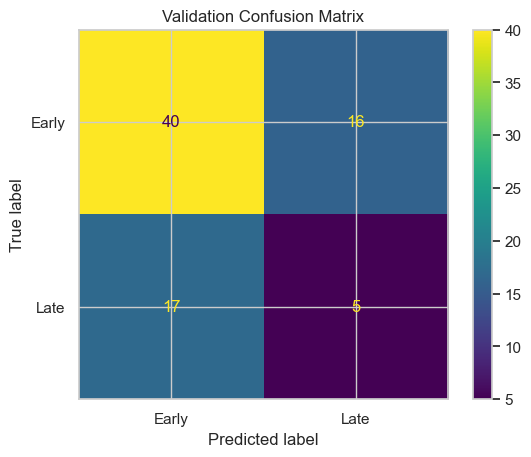

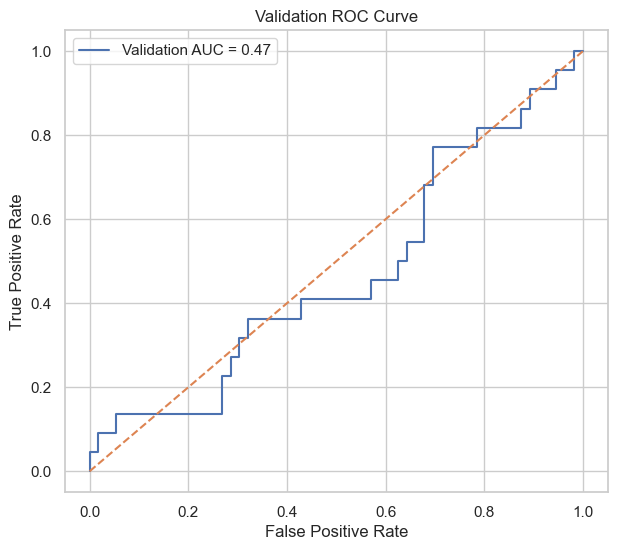

Validation AUC: 0.46834415584415584


In [37]:
# Confusion matrix for validation data
validation_cm = confusion_matrix(y_validation, y_validation_pred, labels=log_reg_model.classes_)

validation_disp = ConfusionMatrixDisplay(
    confusion_matrix=validation_cm,
    display_labels=log_reg_model.classes_
)

validation_disp.plot()
plt.title("Validation Confusion Matrix")
plt.show()

# ROC curve for validation data
# This is useful because logistic regression gives probability-like scores,
# so we can evaluate performance across possible thresholds.
if len(np.unique(y_validation)) == 2:
    y_validation_binary = (y_validation == "Late").astype(int)
    fpr, tpr, thresholds = roc_curve(y_validation_binary, y_validation_scores)
    validation_auc = auc(fpr, tpr)

    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"Validation AUC = {validation_auc:.2f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Validation ROC Curve")
    plt.legend()
    plt.show()

    print("Validation AUC:", validation_auc)
else:
    validation_auc = np.nan
    print("ROC curve was not created because the validation target does not contain both classes.")


,Dataset,Accuracy,Error,Balanced Accuracy,Balanced Error
0,Training,0.786667,0.213333,0.712793,0.287207
1,Validation,0.576923,0.423077,0.470779,0.529221


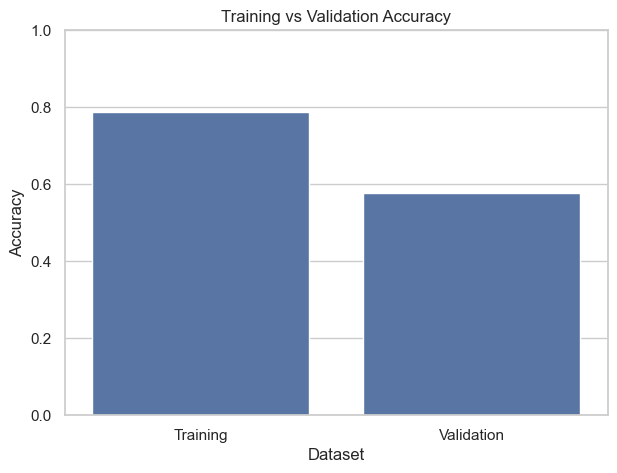

Training error: 0.21333333333333337
Validation error: 0.42307692307692313
Training balanced error: 0.2872073578595318
Validation balanced error: 0.5292207792207793

Model fit interpretation:
The model may be overfitting because training accuracy is much higher than validation accuracy.


In [38]:
# -----------------------------
# Compare in-sample and out-of-sample error
# -----------------------------

train_error = 1 - train_accuracy
validation_error = 1 - validation_accuracy

train_balanced_error = 1 - train_balanced_accuracy
validation_balanced_error = 1 - validation_balanced_accuracy

results_df = pd.DataFrame({
    "Dataset": ["Training", "Validation"],
    "Accuracy": [train_accuracy, validation_accuracy],
    "Error": [train_error, validation_error],
    "Balanced Accuracy": [train_balanced_accuracy, validation_balanced_accuracy],
    "Balanced Error": [train_balanced_error, validation_balanced_error]
})

display(results_df)

# Simple bar plot of training vs validation accuracy
plt.figure(figsize=(7, 5))
sns.barplot(data=results_df, x="Dataset", y="Accuracy")
plt.ylim(0, 1)
plt.title("Training vs Validation Accuracy")
plt.show()

print("Training error:", train_error)
print("Validation error:", validation_error)
print("Training balanced error:", train_balanced_error)
print("Validation balanced error:", validation_balanced_error)

# Basic interpretation helper
accuracy_gap = train_accuracy - validation_accuracy

if accuracy_gap > 0.15:
    model_fit_interpretation = "The model may be overfitting because training accuracy is much higher than validation accuracy."
elif train_accuracy < 0.60 and validation_accuracy < 0.60:
    model_fit_interpretation = "The model may be underfitting because both training and validation accuracy are low."
else:
    model_fit_interpretation = "The model appears reasonably fit as a first-pass baseline, but more validation is needed before drawing strong conclusions."

print("\nModel fit interpretation:")
print(model_fit_interpretation)


## Baseline Model Interpretation

The baseline logistic regression model was trained to predict whether BRCA tumors were Early stage or Late stage using apoptosis-related gene expression.

The model achieved a training accuracy of **0.7867** and a validation accuracy of **0.5692**. The training error was **0.2133**, while the validation error was **0.4238**.

This difference between training and validation performance suggests that the model may be overfitting. In other words, the model appears to learn patterns in the training data that do not transfer as well to new validation samples.

The confusion matrix shows which stage groups the model predicts correctly and where it makes mistakes. The ROC curve and AUC provide an additional way to evaluate how well the model separates Early and Late stage tumors across different decision thresholds.

Overall, the baseline model suggests that apoptosis-related gene expression may contain some information related to tumor stage, but the validation performance is not strong enough to claim that these genes alone are reliable predictors of stage. This supports the need for model improvement and cautious interpretation.

### ***Supervised Model Improvement***

The baseline logistic regression model performed better on the training data than on the validation data, suggesting possible overfitting.

To address this, we test several regularization strengths for logistic regression. Regularization helps prevent overfitting by limiting how strongly the model depends on any one gene. In logistic regression, the parameter `C` controls regularization strength:

- Smaller `C` values mean stronger regularization
- Larger `C` values mean weaker regularization

The final model is selected based on validation balanced accuracy, because balanced accuracy accounts for possible class imbalance between Early and Late stage tumors.

,C,Training Accuracy,Validation Accuracy,Training Balanced Accuracy,Validation Balanced Accuracy,Train-Validation Balanced Accuracy Gap
0,0.01,0.706667,0.461538,0.739967,0.445617,0.294350
1,0.10,0.800000,0.461538,0.807274,0.445617,0.361657
2,1.00,0.813333,0.538462,0.804766,0.499188,0.305578
3,10.00,0.786667,0.538462,0.785535,0.485390,0.300146
4,100.00,0.786667,0.525641,0.785535,0.476461,0.309074


Best regularization C chosen from validation data: 1.0
Best validation balanced accuracy: 0.4991883116883117
Training-validation balanced accuracy gap: 0.3055775745993138


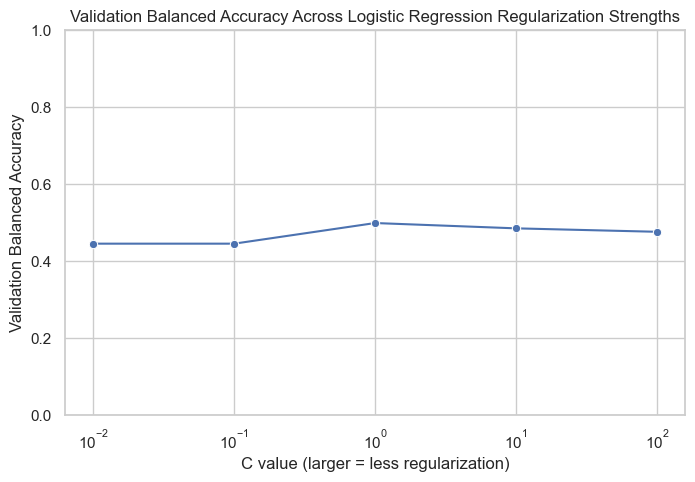

In [39]:
# -----------------------------
# Final project model improvement
# -----------------------------
# We will compare several regularized logistic regression models.
# C controls inverse regularization strength:
#   smaller C = stronger regularization
#   larger C = weaker regularization
# We choose the model that performs best on validation balanced accuracy.

candidate_C_values = [0.01, 0.1, 1, 10, 100]
model_comparison_rows = []
trained_candidate_models = {}

for C_value in candidate_C_values:
    candidate_model = LogisticRegression(
        max_iter=1000,
        random_state=42,
        C=C_value,
        class_weight="balanced",
        solver="liblinear"
    )
    
    # Fit only on the training data
    candidate_model.fit(X_train_scaled, y_train)
    
    # Predict on training and validation data
    candidate_train_pred = candidate_model.predict(X_train_scaled)
    candidate_val_pred = candidate_model.predict(X_validation_scaled)
    
    # Calculate accuracy and balanced accuracy
    candidate_train_acc = accuracy_score(y_train, candidate_train_pred)
    candidate_val_acc = accuracy_score(y_validation, candidate_val_pred)
    candidate_train_bal_acc = balanced_accuracy_score(y_train, candidate_train_pred)
    candidate_val_bal_acc = balanced_accuracy_score(y_validation, candidate_val_pred)
    
    model_comparison_rows.append({
        "C": C_value,
        "Training Accuracy": candidate_train_acc,
        "Validation Accuracy": candidate_val_acc,
        "Training Balanced Accuracy": candidate_train_bal_acc,
        "Validation Balanced Accuracy": candidate_val_bal_acc,
        "Train-Validation Balanced Accuracy Gap": candidate_train_bal_acc - candidate_val_bal_acc
    })
    
    trained_candidate_models[C_value] = candidate_model

model_comparison_df = pd.DataFrame(model_comparison_rows)
display(model_comparison_df)

# Choose the best C by validation balanced accuracy.
# If there is a tie, choose the model with the smaller training-validation gap.
best_row = model_comparison_df.sort_values(
    by=["Validation Balanced Accuracy", "Train-Validation Balanced Accuracy Gap"],
    ascending=[False, True]
).iloc[0]

best_C = best_row["C"]
final_model = trained_candidate_models[best_C]

print("Best regularization C chosen from validation data:", best_C)
print("Best validation balanced accuracy:", best_row["Validation Balanced Accuracy"])
print("Training-validation balanced accuracy gap:", best_row["Train-Validation Balanced Accuracy Gap"])

# Visualize how validation balanced accuracy changes with regularization strength
plt.figure(figsize=(8, 5))
sns.lineplot(data=model_comparison_df, x="C", y="Validation Balanced Accuracy", marker="o")
plt.xscale("log")
plt.ylim(0, 1)
plt.title("Validation Balanced Accuracy Across Logistic Regression Regularization Strengths")
plt.xlabel("C value (larger = less regularization)")
plt.ylabel("Validation Balanced Accuracy")
plt.show()


**Model Improvement Interpretation**

The regularization comparison allows us to choose a model that performs better on validation data rather than simply fitting the training data as closely as possible.

Using validation balanced accuracy as the selection metric is important because Early and Late stage samples may not be equally represented. Balanced accuracy gives equal importance to both classes, so the model is not rewarded for mostly predicting the larger class.

The selected model should be interpreted as the best version of logistic regression tested in this project, not as a perfect model. If validation performance improves and the training-validation gap becomes smaller, that suggests regularization helped reduce overfitting. If performance remains modest, that suggests apoptosis-related genes alone may not provide enough information to strongly predict tumor stage.


Training classification report:
              precision    recall  f1-score   support

       Early       0.90      0.83      0.86        52
        Late       0.67      0.78      0.72        23

    accuracy                           0.81        75
   macro avg       0.78      0.80      0.79        75
weighted avg       0.83      0.81      0.82        75


Validation classification report:
              precision    recall  f1-score   support

       Early       0.72      0.59      0.65        56
        Late       0.28      0.41      0.33        22

    accuracy                           0.54        78
   macro avg       0.50      0.50      0.49        78
weighted avg       0.59      0.54      0.56        78



,Dataset,Accuracy,Error,Balanced Accuracy,Balanced Error,AUC
0,Training,0.813333,0.186667,0.804766,0.195234,0.868729
1,Validation,0.538462,0.461538,0.499188,0.500812,0.474838


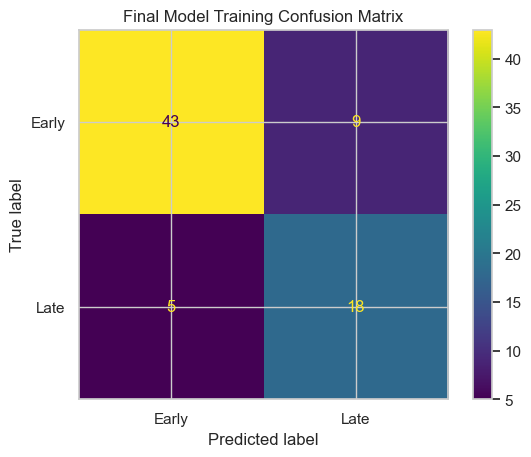

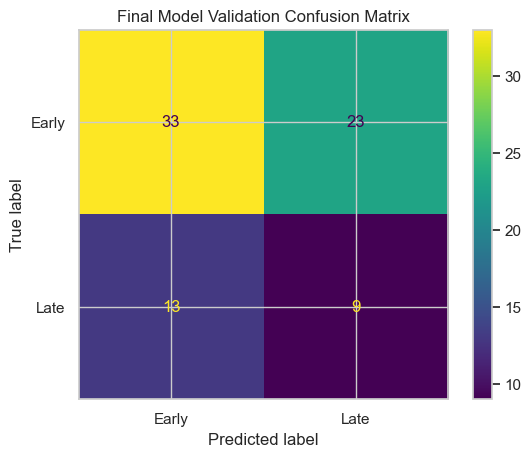

In [40]:
# -----------------------------
# Evaluate the selected final model on training and validation data
# -----------------------------

def evaluate_classifier(model, X_scaled, y_true, dataset_name):
    """
    Evaluate a binary classifier and return common performance metrics.
    This function works for our Early vs Late tumor-stage prediction task.
    """
    y_pred = model.predict(X_scaled)
    y_scores = model.predict_proba(X_scaled)[:, list(model.classes_).index("Late")]
    
    accuracy = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    error = 1 - accuracy
    balanced_error = 1 - balanced_acc
    
    # AUC can only be calculated if both classes are present
    if len(np.unique(y_true)) == 2:
        y_binary = (y_true == "Late").astype(int)
        fpr_values, tpr_values, threshold_values = roc_curve(y_binary, y_scores)
        auc_value = auc(fpr_values, tpr_values)
    else:
        fpr_values, tpr_values, threshold_values = None, None, None
        auc_value = np.nan
    
    print(f"\n{dataset_name} classification report:")
    print(classification_report(y_true, y_pred, zero_division=0))
    
    return {
        "Dataset": dataset_name,
        "Accuracy": accuracy,
        "Error": error,
        "Balanced Accuracy": balanced_acc,
        "Balanced Error": balanced_error,
        "AUC": auc_value,
        "Predictions": y_pred,
        "Scores": y_scores,
        "FPR": fpr_values,
        "TPR": tpr_values,
        "Thresholds": threshold_values
    }

final_train_results = evaluate_classifier(final_model, X_train_scaled, y_train, "Training")
final_validation_results = evaluate_classifier(final_model, X_validation_scaled, y_validation, "Validation")

final_train_validation_summary = pd.DataFrame([
    {key: value for key, value in final_train_results.items() if key not in ["Predictions", "Scores", "FPR", "TPR", "Thresholds"]},
    {key: value for key, value in final_validation_results.items() if key not in ["Predictions", "Scores", "FPR", "TPR", "Thresholds"]}
])

display(final_train_validation_summary)

# Plot confusion matrices for the selected final model
for dataset_name, y_true, y_pred in [
    ("Training", y_train, final_train_results["Predictions"]),
    ("Validation", y_validation, final_validation_results["Predictions"])
]:
    cm = confusion_matrix(y_true, y_pred, labels=final_model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=final_model.classes_)
    disp.plot()
    plt.title(f"Final Model {dataset_name} Confusion Matrix")
    plt.show()


**Final Test Dataset Evaluation**

After selecting the final logistic regression model using the training and validation datasets, we evaluate it on the test dataset.

The test dataset is important because it was not used to train the model or choose the regularization strength. Therefore, test performance provides the best estimate of how well the final model generalizes to unseen data.

The same preprocessing steps are applied to the test set: filtering to BRCA samples, selecting the same apoptosis genes, cleaning tumor stage labels, and applying the scaler that was fit on the training data.

In [41]:
# -----------------------------
# Load and prepare the test dataset
# -----------------------------
# The test dataset is only used at the end, after the model has already been
# selected using the training and validation datasets.

test_metadata_df = pd.read_csv(test_metadata_path, index_col=0)
test_data = pd.read_csv(test_expression_path, index_col=0)

print("Test expression data shape (genes x samples):", test_data.shape)
print("Test metadata shape (samples x features):", test_metadata_df.shape)

# Subset test data to BRCA samples
test_brca_metadata = test_metadata_df[test_metadata_df["cancer_type"] == "BRCA"].copy()
test_brca_sample_ids = test_brca_metadata.index.intersection(test_data.columns)
test_brca_metadata = test_brca_metadata.loc[test_brca_sample_ids].copy()

# Apply the same stage cleaning function used for training and validation
test_brca_metadata["stage_group"] = test_brca_metadata["ajcc_pathologic_tumor_stage"].apply(simplify_stage)

print("\nTest stage group counts:")
print(test_brca_metadata["stage_group"].value_counts(dropna=False))

# Use the same genes and the same column order as the training model
test_missing_genes = [gene for gene in X_train.columns if gene not in test_data.index]
if test_missing_genes:
    raise ValueError(f"These training genes are missing from the test data: {test_missing_genes}")

test_brca_data = test_data.loc[X_train.columns, test_brca_sample_ids]

# Keep only test samples with usable stage labels
test_valid_samples = test_brca_metadata.dropna(subset=["stage_group"]).index

X_test = test_brca_data.T.loc[test_valid_samples].copy()
y_test = test_brca_metadata.loc[test_valid_samples, "stage_group"].copy()

# Make sure test columns match the training columns exactly
X_test = X_test[X_train.columns]

print("\nTest feature matrix shape:", X_test.shape)
print("Test target shape:", y_test.shape)
print("\nTest class balance:")
print(y_test.value_counts())

# Transform test data using the scaler fit on the training data only
X_test_scaled = ml_scaler.transform(X_test)

Test expression data shape (genes x samples): (15716, 1600)
Test metadata shape (samples x features): (1600, 29)

Test stage group counts:
stage_group
Early    55
Late     20
NaN       5
Name: count, dtype: int64

Test feature matrix shape: (75, 17)
Test target shape: (75,)

Test class balance:
stage_group
Early    55
Late     20
Name: count, dtype: int64



Test classification report:
              precision    recall  f1-score   support

       Early       0.70      0.56      0.63        55
        Late       0.23      0.35      0.27        20

    accuracy                           0.51        75
   macro avg       0.47      0.46      0.45        75
weighted avg       0.58      0.51      0.53        75



,Dataset,Accuracy,Error,Balanced Accuracy,Balanced Error,AUC
0,Training,0.813333,0.186667,0.804766,0.195234,0.868729
1,Validation,0.538462,0.461538,0.499188,0.500812,0.474838
2,Test,0.506667,0.493333,0.456818,0.543182,0.454545


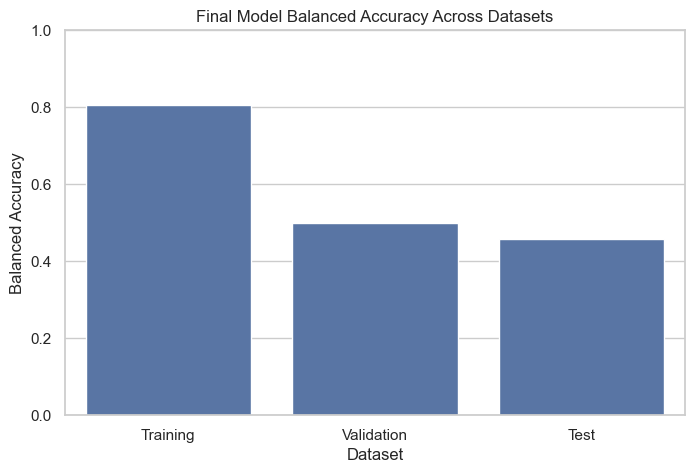

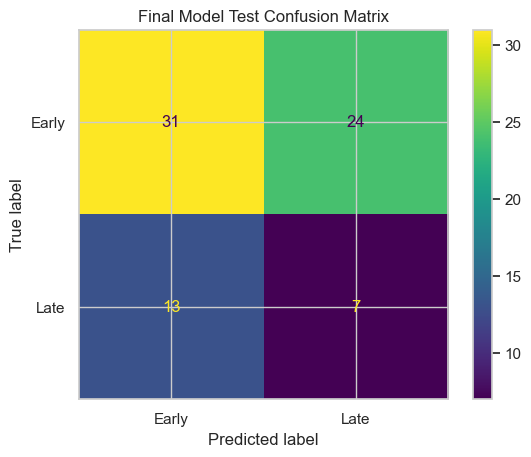

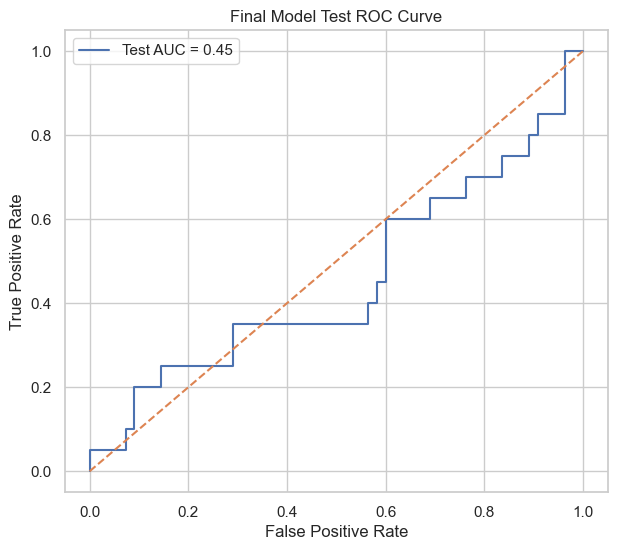

In [42]:
# -----------------------------
# Final model performance on the test dataset
# -----------------------------
final_test_results = evaluate_classifier(final_model, X_test_scaled, y_test, "Test")

final_all_results_summary = pd.DataFrame([
    {key: value for key, value in final_train_results.items() if key not in ["Predictions", "Scores", "FPR", "TPR", "Thresholds"]},
    {key: value for key, value in final_validation_results.items() if key not in ["Predictions", "Scores", "FPR", "TPR", "Thresholds"]},
    {key: value for key, value in final_test_results.items() if key not in ["Predictions", "Scores", "FPR", "TPR", "Thresholds"]}
])

display(final_all_results_summary)

# Plot final performance comparison
plt.figure(figsize=(8, 5))
sns.barplot(data=final_all_results_summary, x="Dataset", y="Balanced Accuracy")
plt.ylim(0, 1)
plt.title("Final Model Balanced Accuracy Across Datasets")
plt.ylabel("Balanced Accuracy")
plt.show()

# Test confusion matrix
final_test_cm = confusion_matrix(y_test, final_test_results["Predictions"], labels=final_model.classes_)
final_test_disp = ConfusionMatrixDisplay(
    confusion_matrix=final_test_cm,
    display_labels=final_model.classes_
)
final_test_disp.plot()
plt.title("Final Model Test Confusion Matrix")
plt.show()

# Test ROC curve
if final_test_results["FPR"] is not None:
    plt.figure(figsize=(7, 6))
    plt.plot(final_test_results["FPR"], final_test_results["TPR"], label=f"Test AUC = {final_test_results['AUC']:.2f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Final Model Test ROC Curve")
    plt.legend()
    plt.show()
else:
    print("Test ROC curve was not created because the test target does not contain both classes.")


In [43]:
# -----------------------------
# Save test-set predictions to a CSV file
# -----------------------------
# This CSV makes the final predictions easy to inspect and submit if needed.

# Save the predictions in the same data folder as the project datasets.
test_predictions_df = pd.DataFrame({
    "sample_id": X_test.index,
    "true_stage_group": y_test.values,
    "predicted_stage_group": final_test_results["Predictions"],
    "late_stage_probability": final_test_results["Scores"]
})

prediction_csv_path = base_path / "brca_apoptosis_test_predictions.csv"
test_predictions_df.to_csv(prediction_csv_path, index=False)

print(f"Saved test predictions to: {prediction_csv_path}")
display(test_predictions_df.head())

Saved test predictions to: C:\Users\15712\OneDrive - University of Virginia\School\OneDrive - University of Virginia\Comp Mod 4\Module-4-Cancer_breckley_chen\data\brca_apoptosis_test_predictions.csv


,sample_id,true_stage_group,predicted_stage_group,late_stage_probability
0,TCGA-E9-A1NH-01A-11R-A14D-07,Early,Early,0.186350
1,TCGA-E2-A1LH-01A-11R-A14D-07,Early,Early,0.325568
2,TCGA-BH-A0B0-01A-21R-A115-07,Early,Early,0.478181
3,TCGA-D8-A73W-01A-22R-A352-07,Late,Early,0.160919
4,TCGA-LL-A50Y-01A-11R-A266-07,Early,Early,0.083622


## Verification and Validation

The main metric used to evaluate the supervised model is **balanced accuracy**. Balanced accuracy calculates the average performance across both classes, Early and Late stage. This is more appropriate than regular accuracy when the classes may not be perfectly balanced, because it prevents the model from appearing successful simply by favoring the more common class.

To verify the analysis, we checked that the same preprocessing steps were applied consistently across the training, validation, and test datasets. The model was fit only on the training data, while the validation data was used for model selection and the test data was reserved for final evaluation. This helps reduce data leakage and gives a more realistic estimate of model performance.

We also used confusion matrices to examine the types of prediction errors made by the model. This is important because overall accuracy alone does not show whether the model is better at predicting Early stage tumors, Late stage tumors, or one class more than the other.

Biologically, this analysis is supported by the fact that apoptosis is a major cancer hallmark. Cancer cells often gain survival advantages by avoiding programmed cell death. However, tumor stage is influenced by many biological processes, not apoptosis alone. Therefore, even if apoptosis-related genes show some predictive value, they should be interpreted as one piece of a larger biological system rather than a complete explanation of breast cancer progression.

**Literature:**

## Conclusions and Ethical Implications

**Conclusions**

This project investigated whether apoptosis-related gene expression patterns are associated with breast cancer tumor stage. We focused on BRCA samples and selected genes involved in apoptosis regulation, including genes that promote cell death, genes that inhibit cell death, and caspases involved in the cell death pathway.

The unsupervised learning analysis provided an exploratory view of the data. PCA helped visualize whether tumors separate based on apoptosis-related expression, while K-means clustering tested whether tumors naturally form expression-based groups. These methods were useful for identifying possible structure in the data, but they do not prove that apoptosis gene expression can predict tumor stage.

The supervised learning analysis tested this question more directly. Logistic regression was used to classify tumors as Early stage or Late stage based on apoptosis-related gene expression. The baseline model performed noticeably better on the training data than on the validation data, suggesting possible overfitting. After testing different regularization strengths, the final model was selected using validation balanced accuracy and then evaluated on the test dataset.

Overall, the results suggest that apoptosis-related gene expression may contain some information related to breast cancer stage, but it is not sufficient by itself to make highly reliable stage predictions. This makes biological sense because tumor stage is influenced by many factors, including tumor size, lymph node involvement, metastasis, immune response, angiogenesis, and other cancer hallmarks beyond resisting apoptosis.

The main conclusion of this project is that apoptosis-related genes are biologically relevant to breast cancer progression, but a small apoptosis-focused gene set is likely too limited to fully predict tumor stage. Future models would likely improve by including additional cancer hallmark genes, more clinical variables, and larger feature sets.

**Ethical Implications**

Machine learning models using cancer data must be interpreted carefully. Although these models can help identify biological patterns, they should not be treated as clinical diagnostic tools unless they are validated on much larger and more diverse patient populations.

One ethical concern is overinterpretation. If a model has only modest validation or test performance, it would be misleading to present it as a reliable predictor of tumor stage. This is especially important in cancer research, where incorrect predictions could affect how people understand disease severity or treatment options.

Another ethical concern is bias in biomedical datasets. If the dataset does not represent patients across different ages, races, ancestries, socioeconomic backgrounds, and cancer subtypes, then the model may not generalize equally to all groups. A model trained on incomplete or biased data could perform better for some patients than others.

For these reasons, the model in this project should be viewed as an educational and exploratory analysis. It can help show how gene expression data and clinical metadata can be combined to study a cancer hallmark, but it should not be used to make medical decisions.

## Limitations and Future Work: 

**Assumptions**

This analysis assumes that the log₂(TPM + 1) expression values are comparable across samples. It also assumes that simplifying tumor stage into Early and Late groups is reasonable for a first-pass classification model.

Another assumption is that the selected apoptosis genes are a useful representation of the resisting-apoptosis cancer hallmark. While these genes are biologically relevant, they do not capture every gene or pathway involved in apoptosis regulation.

**Limitations**

One major limitation of this project is the small gene set. Breast cancer progression is complex and is influenced by many pathways beyond apoptosis, including cell proliferation, immune evasion, angiogenesis, invasion, metastasis, and DNA repair. Because this model only uses apoptosis-related genes, it may miss important signals from other biological processes.

A second limitation is the simplification of tumor stage. Grouping Stage I and Stage II as Early and Stage III and Stage IV as Late makes the model easier to train, but it removes clinical detail. For example, Stage II and Stage III tumors may differ in important ways that are not captured by a binary label.

A third limitation is that the model’s performance depends on the quality and representativeness of the dataset. If certain patient groups or tumor subtypes are underrepresented, the model may not generalize well to all breast cancer cases.

Finally, logistic regression is intentionally simple and interpretable, but it may not capture complex nonlinear relationships between genes. More advanced models could potentially perform better, but they would also require careful validation to avoid overfitting.

**Future Work**

Future work could improve this project by expanding the gene set to include other cancer hallmark pathways in addition to apoptosis. This could help determine whether tumor stage is better predicted by a broader biological signature.

Another improvement would be to include clinical variables such as age, receptor subtype, tumor grade, lymph node status, and treatment information. Combining gene expression data with clinical features may produce a more accurate and biologically meaningful model.

Future analysis could also compare different machine learning models, such as random forests, support vector machines, or regularized models with feature selection. However, any more complex model should still be evaluated carefully using validation and test data.

Overall, this project provides a useful starting point for studying the relationship between apoptosis-related gene expression and breast cancer stage, but stronger conclusions would require more features, more validation, and broader biological context.

## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*